# Counterfactual Explanations Tutorial - Artelt & Hammer Method

Welcome to this tutorial on **Artelt & Hammer (2020)** approach to generating counterfactual explanations with convex density constraints!

## What are Plausible Counterfactual Explanations?

While traditional counterfactual explanations answer: *"What would need to change for a different prediction?"*, **plausible counterfactuals** go one step further by ensuring the generated explanations are realistic and feasible.

The key insight of Artelt & Hammer is that counterfactuals should not only change the prediction but also lie within **high-density regions** of the data distribution, making them more plausible and actionable.


# Import necessary libraries

We'll need additional libraries for density estimation and optimization compared to the Wachter method.


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.optimize import minimize
import seaborn as sns

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## The Artelt & Hammer (2020) Formulation

The paper [*Convex Density Constraints for Computing Plausible Counterfactual Explanations*](https://arxiv.org/pdf/2002.04862) introduces a novel approach that ensures counterfactuals are both **close to the original instance** and **plausible** by lying in high-density regions.

### Key Innovation

Traditional methods like Wachter *et al.* only consider:
- **Proximity**: Minimize distance to original instance  
- **Prediction change**: Achieve desired target prediction  

Artelt & Hammer add a third crucial component:
- **Plausibility**: Ensure counterfactual lies in high-density regions of the data distribution  

### The Optimization Problem

The authors formulate this as a constrained optimization problem:

$$
\begin{aligned}
\min_{x'} \quad & \|x' - x\|_2^2 \\
\text{s.t.} \quad & f(x') = y', \\
& p(x') \ge \tau
\end{aligned}
$$

Where:
- $x'$: Counterfactual instance  
- $x$ Original instance  
- $f(x')$: Model prediction  
- $y'$: Target prediction  
- $p(x')$: Data density at $x'$  
- $\tau$: Density threshold (minimum plausibility level)


## Reformulation as Unconstrained Optimization

To solve this optimization problem using gradient-based methods, we reformulate the constrained problem as an **unconstrained optimization** problem:

### The Loss Function

$$L(x') = \lambda_1 \cdot d(x, x') + \lambda_2 \cdot \ell(f(x'), y') + \lambda_3 \cdot \phi(p(x'))$$

Where:
- **$d(x, x')$**: Distance function (typically L2 distance: $||x' - x||_2^2$)  
- **$\ell(f(x'), y')$**: Loss function measuring how far $f(x')$ is from the target $y'$  
- **$\phi(p(x'))$**: Density penalty function (encourages high-density regions)  
- **$\lambda_1, \lambda_2, \lambda_3$**: Hyperparameters balancing proximity, prediction change, and plausibility  

### Distance Component

Same as Wachter method - encourages proximity:

$$d(x, x') = ||x' - x||_2^2 = \sum_{i=1}^{d} (x'_i - x_i)^2$$

### Prediction Loss Component

Same as Wachter method - encourages correct prediction:

$$\ell(f(x'), y') = \max(0, \tau - (f(x') - 0.5) \cdot (2y' - 1))$$

### Density Penalty Component

The key novelty - encourages plausibility:

$$\phi(p(x')) = -\log(p(x'))$$

This penalty is:
- **Low** when p(x') is high (plausible regions)
- **High** when p(x') is low (implausible regions)

### Density Estimation

To compute p(x'), we need to estimate the data density. Common approaches:

1. **Gaussian Mixture Model (GMM)**: Models data as mixture of Gaussians
2. **Kernel Density Estimation (KDE)**: Non-parametric density estimation
3. **Normalizing Flows**: Deep learning-based density estimation

For this tutorial, we'll use **GMM** as it's efficient and works well for the moons dataset.

### Gradient-Based Optimization

The optimization becomes:

$$x'^{(t+1)} = x'^{(t)} - \alpha \nabla_{x'} L(x'^{(t)})$$

Where the gradient includes the density term:

$$\nabla_{x'} L(x') = \lambda_1 \nabla_{x'} d(x, x') + \lambda_2 \nabla_{x'} \ell(f(x'), y') + \lambda_3 \nabla_{x'} \phi(p(x'))$$

The density gradient requires computing:

$$\nabla_{x'} \phi(p(x')) = -\frac{\nabla_{x'} p(x')}{p(x')}$$

This can be computed using automatic differentiation if p(x') is differentiable (e.g., GMM).


## Dataset: Two Moons

We'll use the same "two moons" dataset for consistency with the Wachter tutorial. This dataset is perfect for demonstrating density constraints because:

1. **Clear density patterns**: Each moon forms a high-density region
2. **Low-density gaps**: Space between moons has low density
3. **Visual interpretability**: Easy to see when counterfactuals are plausible vs. implausible


In [3]:
# Generate the two moons dataset
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

print(f"Training set shape: {X_train_tensor.shape}")
print(f"Test set shape: {X_test_tensor.shape}")
print(
    f"Class distribution - Class 0: {(y_train == 0).sum()}, Class 1: {(y_train == 1).sum()}"
)

Training set shape: torch.Size([800, 2])
Test set shape: torch.Size([200, 2])
Class distribution - Class 0: 400, Class 1: 400


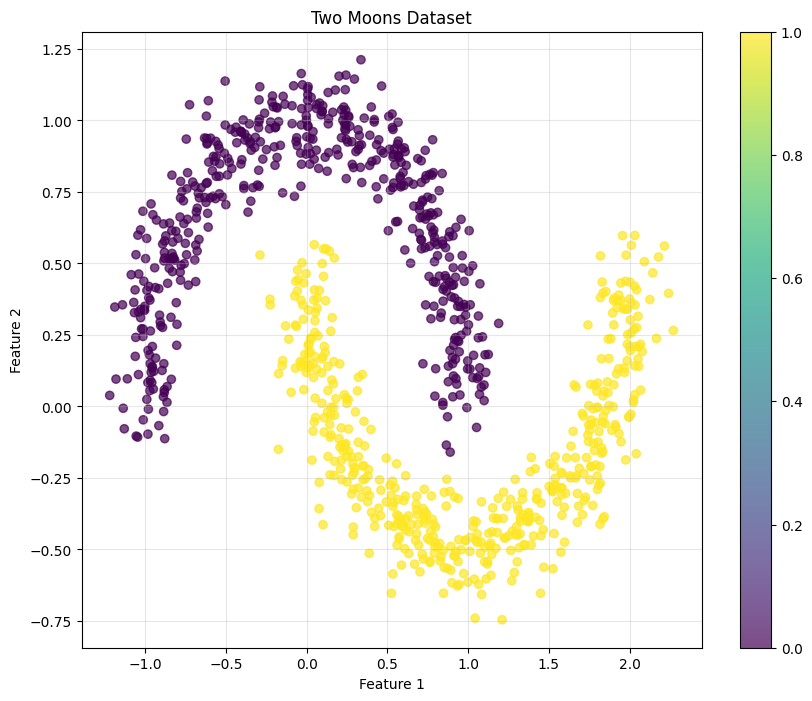

In [ ]:
# Visualize the dataset
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", alpha=0.7)
plt.title("Two Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.show()

## Neural Network Model

We'll use the same neural network architecture as in the Wachter tutorial for consistency.


In [5]:
class LogisticRegression(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)

    def predict_proba(self, x):
        return torch.softmax(self.forward(x), dim=1)

    def predict(self, X_test):
        if isinstance(X_test, np.ndarray):
            X_test = torch.from_numpy(X_test).float()
        with torch.no_grad():
            probs = self.predict_proba(X_test)
            probs = torch.argmax(probs, dim=1)
            return probs.squeeze().float()


model = LogisticRegression(2, 2)

In [6]:
class MultilayerPerceptron(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, output_dim),
        )

    def forward(self, x):
        return self.layers(x)

    def predict_proba(self, x):
        return torch.softmax(self.forward(x), dim=1)

    def predict(self, X_test):
        if isinstance(X_test, np.ndarray):
            X_test = torch.from_numpy(X_test).float()
        with torch.no_grad():
            probs = self.predict_proba(X_test)
            probs = torch.argmax(probs, dim=1)
            return probs.squeeze().float()


model = MultilayerPerceptron(2, 2)

## Model Training


In [7]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Create data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Training loop
num_epochs = 100
train_losses = []
train_accuracies = []

model.train()
for epoch in range(num_epochs):
    epoch_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for batch_X, batch_y in train_loader:
        # Forward pass
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        epoch_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_predictions += batch_y.size(0)
        correct_predictions += (predicted == batch_y).sum().item()

    # Calculate average loss and accuracy for the epoch
    avg_loss = epoch_loss / len(train_loader)
    accuracy = correct_predictions / total_predictions

    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}"
        )

print("Training completed!")

Epoch [20/100], Loss: 0.0002, Accuracy: 1.0000
Epoch [40/100], Loss: 0.0001, Accuracy: 1.0000
Epoch [60/100], Loss: 0.0000, Accuracy: 1.0000
Epoch [80/100], Loss: 0.0000, Accuracy: 1.0000
Epoch [100/100], Loss: 0.0000, Accuracy: 1.0000
Training completed!


/Users/lukasz/genwro/ML-in-PL-counterfactuals/.venv/lib/python3.12/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4324.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


<Axes: >

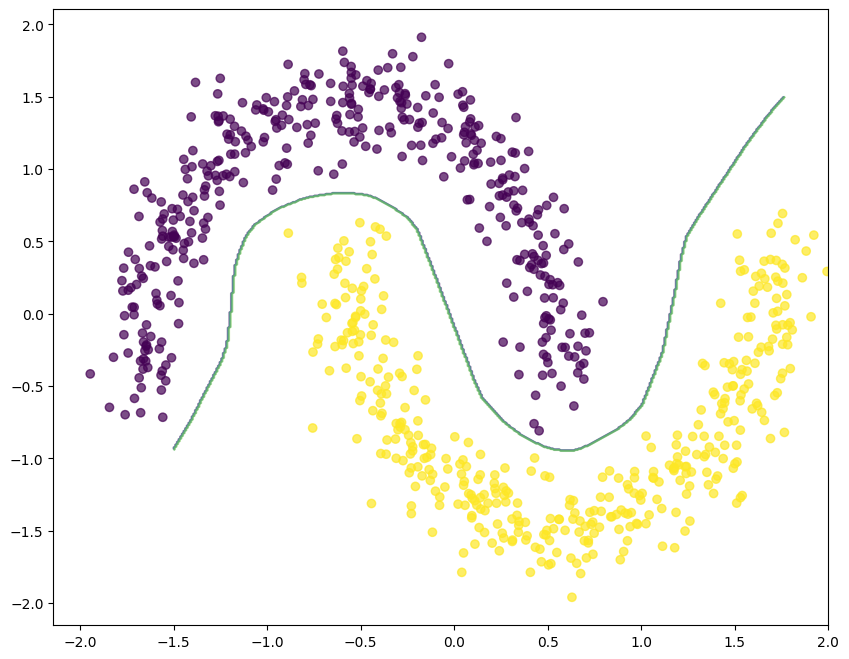

In [ ]:
from src.visualization.plot_utils import plot_classifier_decision_region

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.scatter(
    X_train_tensor.numpy()[:, 0],
    X_train_tensor.numpy()[:, 1],
    c=y_train,
    cmap="viridis",
    alpha=0.7,
)
ax.grid()
plot_classifier_decision_region(ax, model)

NameError: name 'X_train_tensor' is not defined

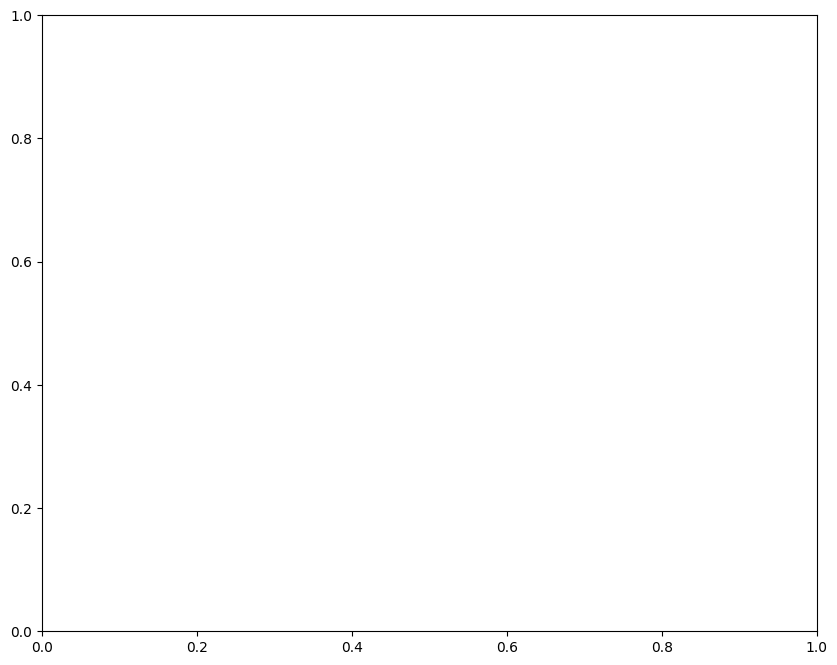

In [1]:
import matplotlib.pyplot as plt
from src.visualization.plot_utils import plot_classifier_decision_region

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.scatter(
    X_train_tensor.numpy()[:, 0],
    X_train_tensor.numpy()[:, 1],
    c=y_train,
    cmap="viridis",
    alpha=0.7,
)
plot_classifier_decision_region(ax, model)

## Density Estimation

Now we need to estimate the data density to implement the plausibility constraint. We'll use a Gaussian Mixture Model (GMM) to model the data distribution.


In [10]:
# Fit Gaussian Mixture Model for density estimation
gmm = GaussianMixture(n_components=4, random_state=42)
X_train_scaled_1 = X_train_scaled[y_train == 1]
gmm.fit(X_train_scaled_1)

print(f"GMM fitted with {gmm.n_components} components")
print(f"Converged: {gmm.converged_}")
print(f"Log-likelihood: {gmm.score(X_train_scaled_1):.4f}")

GMM fitted with 4 components
Converged: True
Log-likelihood: -1.1203


In [11]:
class GMMDensityModel(torch.nn.Module):
    """Simple nn.Module wrapper providing a log-prob interface like MaskedAutoregressiveFlow."""

    def __init__(self, gmm):
        super().__init__()
        self.gmm = gmm

    def forward(self, x, context=None):
        if not isinstance(x, torch.Tensor):
            raise TypeError("x must be a torch.Tensor")
        if x.dim() == 1:
            x = x.unsqueeze(0)
        x_cpu = x.detach().cpu()
        log_prob = self.gmm.score_samples(x_cpu.numpy())
        return torch.from_numpy(log_prob).to(x.device).to(x.dtype)


gmm_density_model = GMMDensityModel(gmm)

---

# 🚀 **YOUR TURN: Implement Plausible Counterfactual Generation**

Now it's time for you to implement the Artelt & Hammer counterfactual generation algorithm!

## Task Overview

Your goal is to implement a `PlausibleCounterfactualGenerator` class that:

1. **Takes an input instance** and finds the closest plausible counterfactual explanation
2. **Uses gradient-based optimization** to minimize the loss function: `L(x') = λ₁ * d(x, x') + λ₂ * ℓ(f(x'), y') + λ₃ * φ(p(x'))`
3. **Ensures plausibility** by incorporating density constraints
4. **Returns the counterfactual instance** that changes the model's prediction while staying in high-density regions

## Implementation Guidelines

### Class Structure
```python
class PlausibleCounterfactualGenerator:
    def __init__(self, model, gmm, lambda1=1.0, lambda2=1.0, lambda3=1.0, lr=0.01, max_iterations=1000):
        # Initialize your plausible counterfactual generator
        pass
    
    def generate(self, x_orig, target_class, tolerance=0.1):
        # Generate plausible counterfactual explanation for x_orig
        # Returns: counterfactual instance, success flag, iterations used
        pass
```

### Key Components to Implement

1. **Distance Function**: Implement L2 distance `d(x, x')`
2. **Prediction Loss**: Choose between margin loss or cross-entropy loss
3. **Density Penalty**: Implement `φ(p(x')) = -log(p(x'))`
4. **Gradient Optimization**: Use PyTorch's autograd for gradient computation
5. **Stopping Criteria**: Stop when target prediction is achieved or max iterations reached

### Hints

- Initialize `x'` as a copy of the original input `x`
- Make `x'` a PyTorch tensor with `requires_grad=True`
- Use `torch.optim.Adam` or `torch.optim.SGD` for optimization
- For density computation, you'll need to convert PyTorch tensors to numpy for GMM
- Consider using `torch.autograd.Function` for custom density gradient computation
- Track all three loss components separately for debugging

### Density Gradient Computation

The tricky part is computing gradients through the GMM density function. You have several options:

1. **Finite differences**: Approximate gradients numerically
2. **Custom autograd function**: Implement the GMM gradient manually
3. **PyTorch GMM**: Use a PyTorch implementation of GMM (if available)

For simplicity, you can start with finite differences and then optimize if needed.

## Your Implementation Space

👇 **Write your code in the cells below** 👇


In [ ]:
class PlausibleCounterfactualGenerator:
    def __init__(self):
        pass

    def generate(self):
        pass


---

# 📊 **Visualization Space**

Once you've implemented the counterfactual generator, use this space to create visualizations that compare:

1. **Original vs Counterfactual**: Show the original instance and its counterfactual
2. **Density Comparison**: Show where counterfactuals lie in the density landscape
3. **Loss Components**: Plot the evolution of distance, prediction, and density losses
4. **Comparison with Wachter**: Compare plausible vs. non-plausible counterfactuals

👇 **Add your visualizations here** 👇


In [13]:
cf_generator = PlausibleCounterfactualGenerator(model, gmm, lambda3=1)
X_test_orig = X_test_tensor[y_test_tensor == 0]
X_test_cfs = cf_generator.generate(X_test_orig, 1)

# Expected plot

![artelt_vis](../assets/artelt_example.png)

/Users/lukasz/genwro/ML-in-PL-counterfactuals/src/visualization/show_counterfactuals.py:35: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/Users/lukasz/genwro/ML-in-PL-counterfactuals/src/visualization/show_counterfactuals.py:43: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(


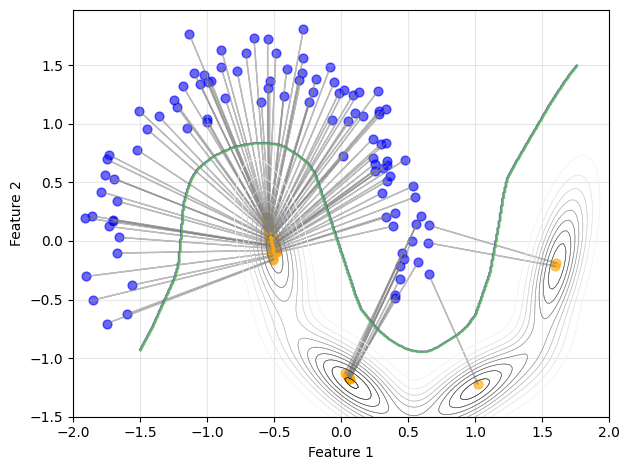

In [14]:
from src.visualization.show_counterfactuals import plot_counterfactuals

plot_counterfactuals(X_test_orig, X_test_cfs, 10, model, gen_model=gmm_density_model)

In [15]:
# Import metrics
from src.metrics.metrics import CFMetrics

# Prepare data for metrics calculation
# Convert tensors to numpy arrays
X_cf_np = X_test_cfs.detach().numpy()
X_test_np = X_test_orig.detach().numpy()
X_train_np = X_train_tensor.detach().numpy()
y_train_np = y_train_tensor.detach().numpy()
y_test_np = y_test_tensor[y_test_tensor == 0].detach().numpy()

# Create target labels (we want to flip from class 0 to class 1)
y_target_np = np.ones_like(y_test_np)  # Target class is 1

# Define feature types (both features are continuous in the two moons dataset)
continuous_features = [0, 1]  # Both features are continuous
categorical_features = []  # No categorical features

metrics_cf = CFMetrics(
    X_cf=X_cf_np,
    y_target=y_target_np,
    X_train=X_train_np,
    y_train=y_train_np,
    X_test=X_test_np,
    y_test=y_test_np,
    disc_model=model,
    gen_model=gmm_density_model,
    continuous_features=continuous_features,
    categorical_features=categorical_features,
    ratio_cont=None,
    prob_plausibility_threshold=-1.7,
)

metrics = {
    "coverage": metrics_cf.coverage(),
    "validity": metrics_cf.validity(),
    "sparsity": metrics_cf.sparsity(),
    "proximity_continuous_euclidean": metrics_cf.feature_distance(
        continuous_metric="euclidean"
    ),
    "proximity_continuous_manhattan": metrics_cf.feature_distance(
        continuous_metric="cityblock"
    ),
    "proximity_continuous_mad": metrics_cf.feature_distance(
        continuous_metric="mad", X_train=X_train_np
    ),
    "prob_plausibility": metrics_cf.prob_plausibility(cf=True),
    "log_density_cf": metrics_cf.log_density(cf=True),
    "lof_scores_cf": metrics_cf.lof_scores(cf=True),
    "isolation_forest_scores_cf": metrics_cf.isolation_forest_scores(cf=True),
}

print("\n=== Counterfactual Metrics Results ===")
print(f"Coverage: {metrics['coverage']:.4f}")
print(f"Validity: {metrics['validity']:.4f}")
print(f"Sparsity: {metrics['sparsity']:.4f}")
print(f"Proximity (Euclidean): {metrics['proximity_continuous_euclidean']:.4f}")
print(f"Proximity (Manhattan): {metrics['proximity_continuous_manhattan']:.4f}")
print(f"Proximity (MAD): {metrics['proximity_continuous_mad']:.4f}")
print(f"Probability Plausibility: {metrics['prob_plausibility']:.4f}")
print(f"Log Density (CF): {metrics['log_density_cf']:.4f}")
print(f"LOF Scores (CF): {metrics['lof_scores_cf']:.4f}")
print(f"Isolation Forest Scores (CF): {metrics['isolation_forest_scores_cf']:.4f}")


=== Counterfactual Metrics Results ===
Coverage: 1.0000
Validity: 1.0000
Sparsity: 1.0000
Proximity (Euclidean): 1.2227
Proximity (Manhattan): 1.5595
Proximity (MAD): 1.9988
Probability Plausibility: 1.0000
Log Density (CF): -0.5501
LOF Scores (CF): 0.9828
Isolation Forest Scores (CF): 0.0307


## Summary

In this tutorial, you've learned about the **Artelt & Hammer (2020)** approach to generating plausible counterfactual explanations:

### Key Concepts

1. **Plausibility Constraint**: Counterfactuals should lie in high-density regions of the data distribution
2. **Three-Component Loss**: Distance + Prediction + Density penalty
3. **Density Estimation**: Using GMM to model data distribution
4. **Gradient Optimization**: Minimizing the combined loss function

### Advantages over Wachter Method

- **More realistic**: Counterfactuals are more likely to occur in practice
- **Better interpretability**: Users can trust that changes are feasible
- **Robust**: Less likely to generate out-of-distribution examples

### Challenges

- **Computational complexity**: Requires density estimation and gradient computation
- **Hyperparameter tuning**: Need to balance three loss components
- **Density estimation quality**: Results depend on the quality of density model

### Next Steps

Consider exploring:
- Different density estimation methods (KDE, Normalizing Flows)
- Adaptive hyperparameter selection
- Comparison with other plausibility constraints
- Application to higher-dimensional datasets
